**IMPORTs**

In [29]:
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

**FONCTIONS UTILES**

In [30]:
def add_labels(x, y, labels):
    for i in range(len(x)):
        plt.text(x[i], y[i], labels[i])

def intersection(liste1, liste2):
    return list(set(liste1) & set(liste2))

def yes_no_to_bool(yes_no):
    if yes_no.lower() in ("yes", "oui", "si"):
        return True
    elif yes_no.lower() in ("non", "no"):
        return False
    else:
        return None


def column_details(df, save_csv=False, filename="column_details.csv"):
    results = []
    
    for col in df.columns:
        series = df[col]
        dtype = series.dtype
        
        info = {
            "Colonne": col,
            "Type": dtype,
            "Nulls": series.isna().sum(),
            "Nulls_%": round(series.isna().mean() * 100, 1),
            "Min": None, "Max": None, "Moyenne": None,
            "Uniques": None, "Top_3": None
        }
        
        if dtype in ['int64', 'float64']:
            info["Min"] = series.min()
            info["Max"] = series.max()
            info["Moyenne"] = round(series.mean(), 2)
        
        elif dtype == 'object' or str(dtype) == 'category':
            info["Uniques"] = series.nunique()
            info["Top_3"] = str(series.value_counts().head(3).to_dict())
        
        elif 'datetime' in str(dtype):
            info["Min"] = series.min()
            info["Max"] = series.max()
        
        results.append(info)
        
        # Affichage console
        print(f"Colonne : {col}")
        print(f"  Type    : {dtype}")
        print(f"  Nulls   : {info['Nulls']} ({info['Nulls_%']}%)")
        if info["Min"] is not None:
            print(f"  Min     : {info['Min']}")
            print(f"  Max     : {info['Max']}")
        if info["Moyenne"] is not None:
            print(f"  Moyenne : {info['Moyenne']}")
        if info["Uniques"] is not None:
            print(f"  Uniques : {info['Uniques']}")
            print(f"  Top 3   : {info['Top_3']}")
        print()
    
    results_df = pd.DataFrame(results)
    
    if save_csv:
        results_df.to_csv(filename, index=False, encoding="utf-8-sig")
        print(f"✅ Sauvegardé dans '{filename}'")
    
    return results_df

In [31]:
student_mat = pd.read_csv("donnees/student-mat.csv")

In [32]:
student_por = pd.read_csv("donnees/student-por.csv")
student_por.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

In [33]:
student_mat.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15


In [34]:
student_por.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,6,12,12,13
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,13,12,13
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,2,10,13,13
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,15,16,17
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,12,12,13


In [35]:
mat_col = student_mat.columns
por_col = student_por.columns

common = intersection(mat_col, por_col)
print(f"colonne commune : {len(common)}")

column_details(student_mat, save_csv=True, filename="column_details_mat.csv")
column_details(student_por, save_csv=True, filename="column_details_por.csv")

colonne commune : 33
Colonne : school
  Type    : str
  Nulls   : 0 (0.0%)

Colonne : sex
  Type    : str
  Nulls   : 0 (0.0%)

Colonne : age
  Type    : int64
  Nulls   : 0 (0.0%)
  Min     : 15
  Max     : 22
  Moyenne : 16.7

Colonne : address
  Type    : str
  Nulls   : 0 (0.0%)

Colonne : famsize
  Type    : str
  Nulls   : 0 (0.0%)

Colonne : Pstatus
  Type    : str
  Nulls   : 0 (0.0%)

Colonne : Medu
  Type    : int64
  Nulls   : 0 (0.0%)
  Min     : 0
  Max     : 4
  Moyenne : 2.75

Colonne : Fedu
  Type    : int64
  Nulls   : 0 (0.0%)
  Min     : 0
  Max     : 4
  Moyenne : 2.52

Colonne : Mjob
  Type    : str
  Nulls   : 0 (0.0%)

Colonne : Fjob
  Type    : str
  Nulls   : 0 (0.0%)

Colonne : reason
  Type    : str
  Nulls   : 0 (0.0%)

Colonne : guardian
  Type    : str
  Nulls   : 0 (0.0%)

Colonne : traveltime
  Type    : int64
  Nulls   : 0 (0.0%)
  Min     : 1
  Max     : 4
  Moyenne : 1.45

Colonne : studytime
  Type    : int64
  Nulls   : 0 (0.0%)
  Min     : 1
  Max 

,Colonne,Type,Nulls,Nulls_%,Min,Max,Moyenne,Uniques,Top_3
0,school,str,0,0.0,NaN,NaN,NaN,None,None
1,sex,str,0,0.0,NaN,NaN,NaN,None,None
2,age,int64,0,0.0,15.0,22.0,16.74,None,None
3,address,str,0,0.0,NaN,NaN,NaN,None,None
4,famsize,str,0,0.0,NaN,NaN,NaN,None,None
5,Pstatus,str,0,0.0,NaN,NaN,NaN,None,None
6,Medu,int64,0,0.0,0.0,4.0,2.51,None,None
7,Fedu,int64,0,0.0,0.0,4.0,2.31,None,None
8,Mjob,str,0,0.0,NaN,NaN,NaN,None,None
9,Fjob,str,0,0.0,NaN,NaN,NaN,None,None


**Introduction** *INFO*:

- Le DataFrame *Student_mat* est composé de 33 colonnes et 395 lignes de données

- Le DataFrame *Student_por* est composé de 33 colonnes et 649 lignes de données

Les deux DataFrames possèdent les même colonnes et ne possède aucune données manquantes

Pour voir les colonnes voir columns_details.md

**1ere étape** On va commencer par nettoyer les types des données de toute les données (str)

Exemple : Romantice -> yes/no => True/False

In [ ]:
to_convert_bool_categorical = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian']

for col in to_convert_bool_categorical:
    student_mat[col] = pd.Categorical(student_mat[col])
for col in to_convert_bool_categorical:
    student_por[col] = pd.Categorical(student_por[col])

**Conversion de colonne en Bool**

In [ ]:
to_convert_bool_col = ['schoolsup', 'famsup', 'paid', 'activities', 'higher', 'nursery', 'internet', 'romantic']

for col in to_convert_bool_col:
    student_mat[col] = student_mat[col].apply(yes_no_to_bool)

for col in to_convert_bool_col:
    student_por[col] = student_por[col].apply(yes_no_to_bool)


In [38]:
column_details(student_mat, save_csv=True, filename="column_details_mat_post_treatment.csv")

Colonne : school
  Type    : category
  Nulls   : 0 (0.0%)
  Uniques : 2
  Top 3   : {'GP': 349, 'MS': 46}

Colonne : sex
  Type    : category
  Nulls   : 0 (0.0%)
  Uniques : 2
  Top 3   : {'F': 208, 'M': 187}

Colonne : age
  Type    : int64
  Nulls   : 0 (0.0%)
  Min     : 15
  Max     : 22
  Moyenne : 16.7

Colonne : address
  Type    : category
  Nulls   : 0 (0.0%)
  Uniques : 2
  Top 3   : {'U': 307, 'R': 88}

Colonne : famsize
  Type    : category
  Nulls   : 0 (0.0%)
  Uniques : 2
  Top 3   : {'GT3': 281, 'LE3': 114}

Colonne : Pstatus
  Type    : category
  Nulls   : 0 (0.0%)
  Uniques : 2
  Top 3   : {'T': 354, 'A': 41}

Colonne : Medu
  Type    : int64
  Nulls   : 0 (0.0%)
  Min     : 0
  Max     : 4
  Moyenne : 2.75

Colonne : Fedu
  Type    : int64
  Nulls   : 0 (0.0%)
  Min     : 0
  Max     : 4
  Moyenne : 2.52

Colonne : Mjob
  Type    : category
  Nulls   : 0 (0.0%)
  Uniques : 5
  Top 3   : {'other': 141, 'services': 103, 'at_home': 59}

Colonne : Fjob
  Type    : cat

,Colonne,Type,Nulls,Nulls_%,Min,Max,Moyenne,Uniques,Top_3
0,school,category,0,0.0,NaN,NaN,NaN,2.0,"{'GP': 349, 'MS': 46}"
1,sex,category,0,0.0,NaN,NaN,NaN,2.0,"{'F': 208, 'M': 187}"
2,age,int64,0,0.0,15.0,22.0,16.70,NaN,NaN
3,address,category,0,0.0,NaN,NaN,NaN,2.0,"{'U': 307, 'R': 88}"
4,famsize,category,0,0.0,NaN,NaN,NaN,2.0,"{'GT3': 281, 'LE3': 114}"
5,Pstatus,category,0,0.0,NaN,NaN,NaN,2.0,"{'T': 354, 'A': 41}"
6,Medu,int64,0,0.0,0.0,4.0,2.75,NaN,NaN
7,Fedu,int64,0,0.0,0.0,4.0,2.52,NaN,NaN
8,Mjob,category,0,0.0,NaN,NaN,NaN,5.0,"{'other': 141, 'services': 103, 'at_home': 59}"
9,Fjob,category,0,0.0,NaN,NaN,NaN,5.0,"{'other': 217, 'services': 111, 'teacher': 29}"


In [39]:
column_details(student_por, save_csv=True, filename="column_details_por_post_treatment.csv")

Colonne : school
  Type    : category
  Nulls   : 0 (0.0%)
  Uniques : 2
  Top 3   : {'GP': 423, 'MS': 226}

Colonne : sex
  Type    : category
  Nulls   : 0 (0.0%)
  Uniques : 2
  Top 3   : {'F': 383, 'M': 266}

Colonne : age
  Type    : int64
  Nulls   : 0 (0.0%)
  Min     : 15
  Max     : 22
  Moyenne : 16.74

Colonne : address
  Type    : category
  Nulls   : 0 (0.0%)
  Uniques : 2
  Top 3   : {'U': 452, 'R': 197}

Colonne : famsize
  Type    : category
  Nulls   : 0 (0.0%)
  Uniques : 2
  Top 3   : {'GT3': 457, 'LE3': 192}

Colonne : Pstatus
  Type    : category
  Nulls   : 0 (0.0%)
  Uniques : 2
  Top 3   : {'T': 569, 'A': 80}

Colonne : Medu
  Type    : int64
  Nulls   : 0 (0.0%)
  Min     : 0
  Max     : 4
  Moyenne : 2.51

Colonne : Fedu
  Type    : int64
  Nulls   : 0 (0.0%)
  Min     : 0
  Max     : 4
  Moyenne : 2.31

Colonne : Mjob
  Type    : category
  Nulls   : 0 (0.0%)
  Uniques : 5
  Top 3   : {'other': 258, 'services': 136, 'at_home': 135}

Colonne : Fjob
  Type    :

,Colonne,Type,Nulls,Nulls_%,Min,Max,Moyenne,Uniques,Top_3
0,school,category,0,0.0,NaN,NaN,NaN,2.0,"{'GP': 423, 'MS': 226}"
1,sex,category,0,0.0,NaN,NaN,NaN,2.0,"{'F': 383, 'M': 266}"
2,age,int64,0,0.0,15.0,22.0,16.74,NaN,NaN
3,address,category,0,0.0,NaN,NaN,NaN,2.0,"{'U': 452, 'R': 197}"
4,famsize,category,0,0.0,NaN,NaN,NaN,2.0,"{'GT3': 457, 'LE3': 192}"
5,Pstatus,category,0,0.0,NaN,NaN,NaN,2.0,"{'T': 569, 'A': 80}"
6,Medu,int64,0,0.0,0.0,4.0,2.51,NaN,NaN
7,Fedu,int64,0,0.0,0.0,4.0,2.31,NaN,NaN
8,Mjob,category,0,0.0,NaN,NaN,NaN,5.0,"{'other': 258, 'services': 136, 'at_home': 135}"
9,Fjob,category,0,0.0,NaN,NaN,NaN,5.0,"{'other': 367, 'services': 181, 'at_home': 42}"


# ACP #

### 1. One-hot encoding
Permet d'inclure les variables catégorielles dans l'ACP

### 2. Variables centré réduite
Les variables n'ont pas la même échelles

## Première version avec toute les variables

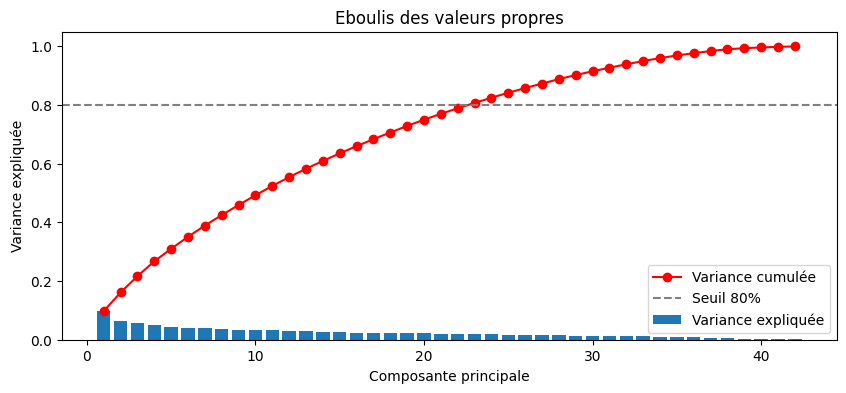

Variance cumulée par composante :
  CP1 : 9.78%
  CP2 : 16.10%
  CP3 : 21.67%
  CP4 : 26.72%
  CP5 : 31.02%
  CP6 : 35.07%
  CP7 : 38.92%
  CP8 : 42.48%
  CP9 : 45.92%
  CP10 : 49.25%
  CP11 : 52.42%
  CP12 : 55.43%
  CP13 : 58.27%
  CP14 : 60.95%
  CP15 : 63.54%
  CP16 : 65.98%
  CP17 : 68.37%
  CP18 : 70.64%
  CP19 : 72.87%
  CP20 : 75.01%
  CP21 : 77.01%
  CP22 : 78.91%
  CP23 : 80.72%
  => 23 composantes suffisent pour 80% de variance
✅ Sauvegardé dans 'variance_expliquee.csv'


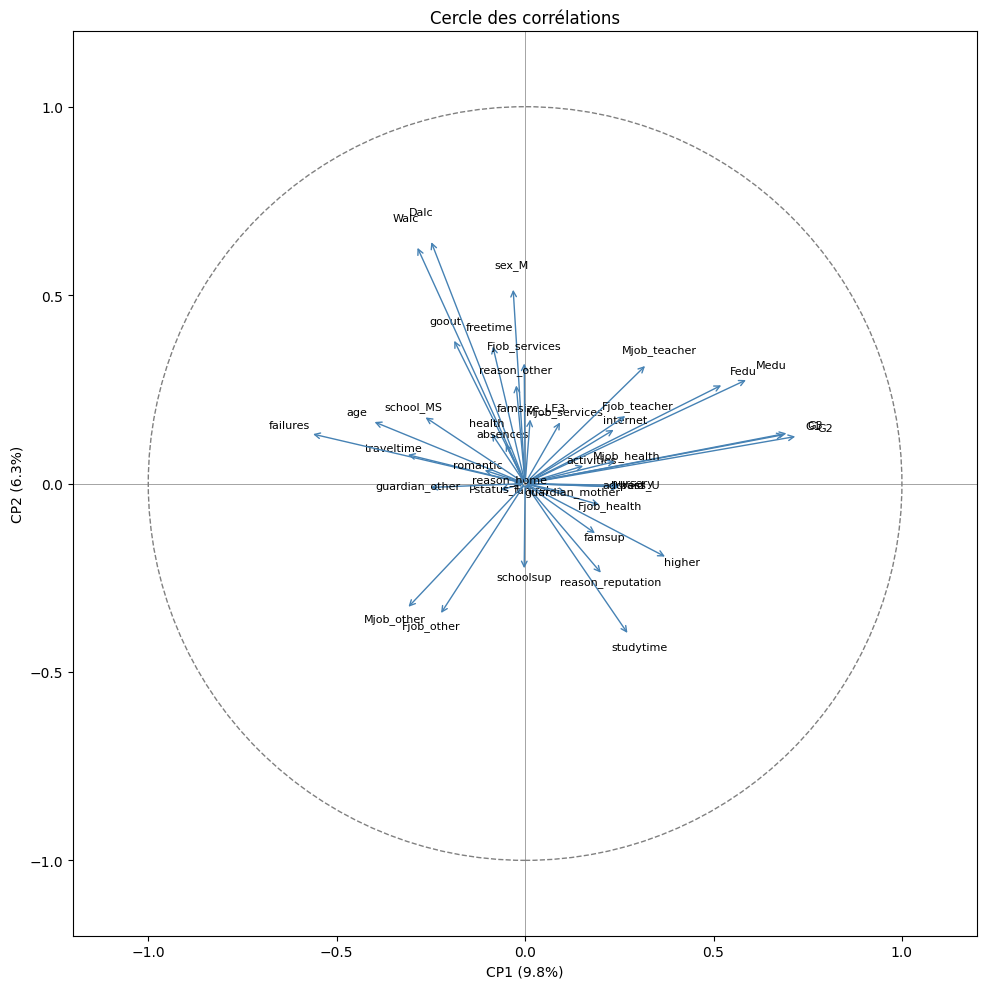

In [54]:
# ---- 1. Séparation numériques / catégorielles ----
num_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
            'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
            'absences', 'G1', 'G2', 'G3']

cat_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus',
            'Mjob', 'Fjob', 'reason', 'guardian']

bool_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'nursery',
             'higher', 'internet', 'romantic']

# ---- 2. Encodage one-hot des catégorielles ----
encoder = OneHotEncoder(sparse_output=False, drop='first')
cat_encoded = encoder.fit_transform(student_mat[cat_cols])
cat_encoded_df = pd.DataFrame(
    cat_encoded,
    columns=encoder.get_feature_names_out(cat_cols)
)

# Booléens en int (True/False -> 1/0)
bool_df = student_mat[bool_cols].astype(int)

# ---- 3. Assemblage du DataFrame final ----
df_acp = pd.concat([
    student_mat[num_cols].reset_index(drop=True),
    bool_df.reset_index(drop=True),
    cat_encoded_df.reset_index(drop=True)
], axis=1)

# ---- 4. Centrage-réduction ----
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_acp)

# ---- 5. ACP ----
pca = PCA()
pca.fit(X_scaled)

# ---- 6. Variance expliquée ----
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(10, 4))
plt.bar(range(1, len(explained)+1), explained, label='Variance expliquée')
plt.plot(range(1, len(explained)+1), cumulative, color='red',
         marker='o', label='Variance cumulée')
plt.axhline(y=0.8, color='gray', linestyle='--', label='Seuil 80%')
plt.xlabel('Composante principale')
plt.ylabel('Variance expliquée')
plt.title('Eboulis des valeurs propres')
plt.legend()
plt.show()

print("Variance cumulée par composante :")
for i, v in enumerate(cumulative):
    print(f"  CP{i+1} : {v:.2%}")
    if v >= 0.80:
        print(f"  => {i+1} composantes suffisent pour 80% de variance")
        break

variance_df = pd.DataFrame({
    'composante': [f'CP{i+1}' for i in range(len(explained))],
    'variance_expliquee_%': (explained * 100).round(2),
    'variance_cumulee_%': (cumulative * 100).round(2)
})

variance_df.to_csv('variance_expliquee.csv', index=False)
print("✅ Sauvegardé dans 'variance_expliquee.csv'")

# ---- 7. Cercle des corrélations ----
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

# Corrélations variables/composantes
correlations = pca_2.components_.T * np.sqrt(pca_2.explained_variance_)

fig, ax = plt.subplots(figsize=(10, 10))

# Flèches
for i, var in enumerate(df_acp.columns):
    ax.annotate("", xy=(correlations[i, 0], correlations[i, 1]),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="steelblue"))
    ax.text(correlations[i, 0] * 1.1, correlations[i, 1] * 1.1,
            var, fontsize=8, ha='center')

# Cercle
cercle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
ax.add_patch(cercle)

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel(f'CP1 ({pca_2.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'CP2 ({pca_2.explained_variance_ratio_[1]:.1%})')
ax.set_title('Cercle des corrélations')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## Deuxième version avec moins de variables

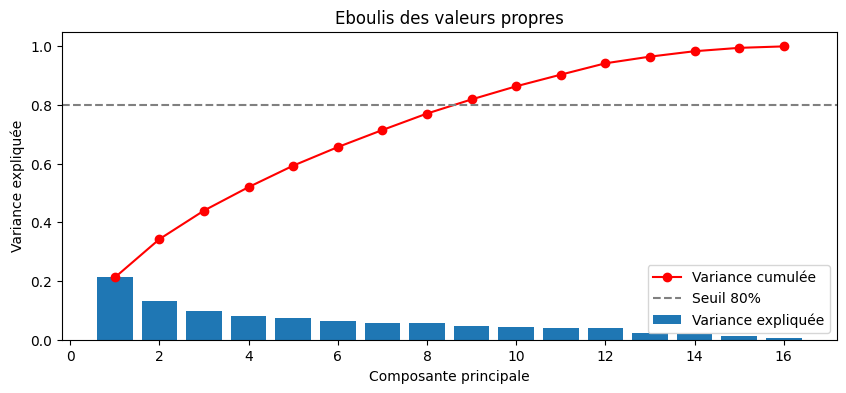

Variance cumulée par composante :
  CP1 : 21.22%
  CP2 : 34.30%
  CP3 : 44.04%
  CP4 : 52.03%
  CP5 : 59.34%
  CP6 : 65.67%
  CP7 : 71.49%
  CP8 : 77.10%
  CP9 : 81.92%
  => 9/16 composantes suffisent pour 80% de variance


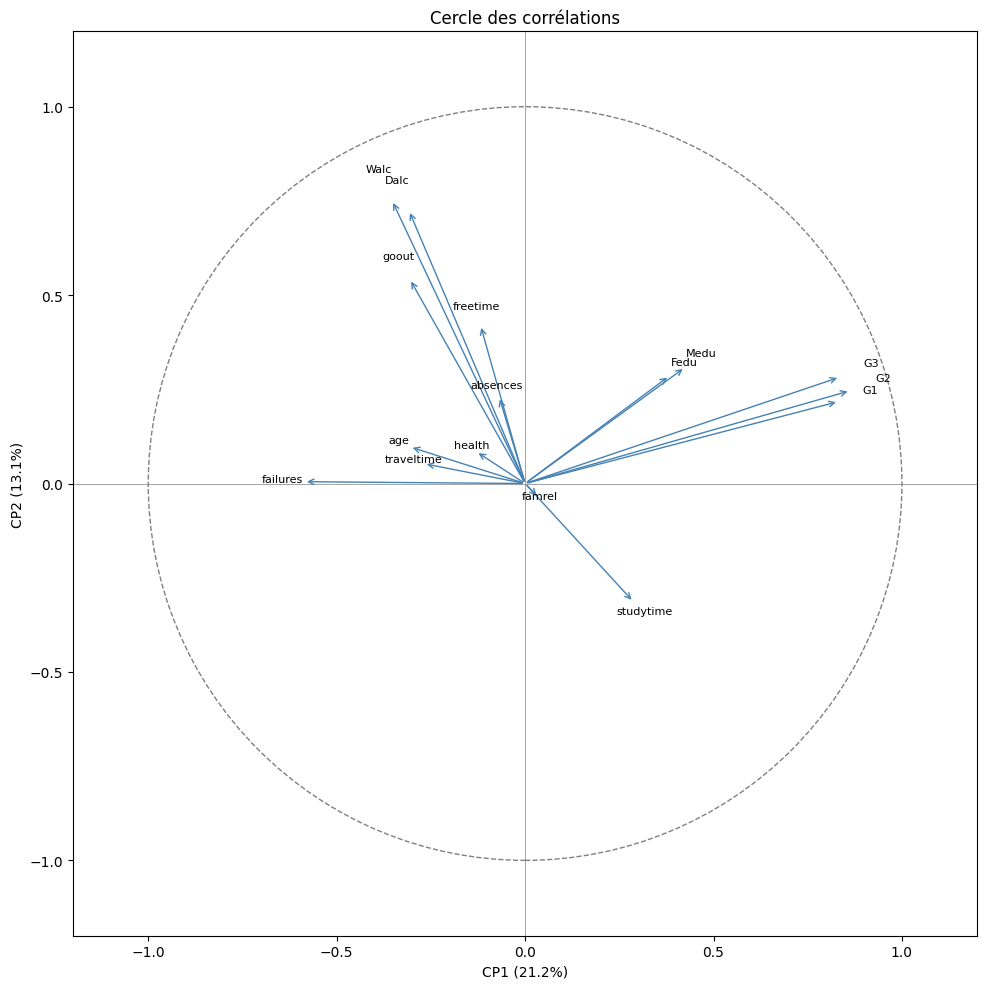

In [46]:
# ---- 1. Séparation numériques / catégorielles ----
num_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
            'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
            'absences', 'G1', 'G2', 'G3']

cat_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus',
            'Mjob', 'Fjob', 'reason', 'guardian']

bool_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'nursery',
             'higher', 'internet', 'romantic']

# ---- 2. Encodage one-hot des catégorielles ----
encoder = OneHotEncoder(sparse_output=False, drop='first')
cat_encoded = encoder.fit_transform(student_mat[cat_cols])
cat_encoded_df = pd.DataFrame(
    cat_encoded,
    columns=encoder.get_feature_names_out(cat_cols)
)

# Booléens en int (True/False -> 1/0)
bool_df = student_mat[bool_cols].astype(int)

# ---- 3. Assemblage du DataFrame final ----
df_acp = pd.concat([
    student_mat[num_cols].reset_index(drop=True),
], axis=1)

# ---- 4. Centrage-réduction ----
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_acp)

# ---- 5. ACP ----
pca = PCA()
pca.fit(X_scaled)

# ---- 6. Variance expliquée ----
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(10, 4))
plt.bar(range(1, len(explained)+1), explained, label='Variance expliquée')
plt.plot(range(1, len(explained)+1), cumulative, color='red',
         marker='o', label='Variance cumulée')
plt.axhline(y=0.8, color='gray', linestyle='--', label='Seuil 80%')
plt.xlabel('Composante principale')
plt.ylabel('Variance expliquée')
plt.title('Eboulis des valeurs propres')
plt.legend()
plt.show()

print("Variance cumulée par composante :")
for i, v in enumerate(cumulative):
    print(f"  CP{i+1} : {v:.2%}")
    if v >= 0.80:
        print(f"  => {i+1}/{len(num_cols)} composantes suffisent pour 80% de variance")
        break

# ---- 7. Cercle des corrélations ----
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

# Corrélations variables/composantes
correlations = pca_2.components_.T * np.sqrt(pca_2.explained_variance_)

fig, ax = plt.subplots(figsize=(10, 10))

# Flèches
for i, var in enumerate(df_acp.columns):
    ax.annotate("", xy=(correlations[i, 0], correlations[i, 1]),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="steelblue"))
    ax.text(correlations[i, 0] * 1.1, correlations[i, 1] * 1.1,
            var, fontsize=8, ha='center')

# Cercle
cercle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
ax.add_patch(cercle)

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel(f'CP1 ({pca_2.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'CP2 ({pca_2.explained_variance_ratio_[1]:.1%})')
ax.set_title('Cercle des corrélations')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

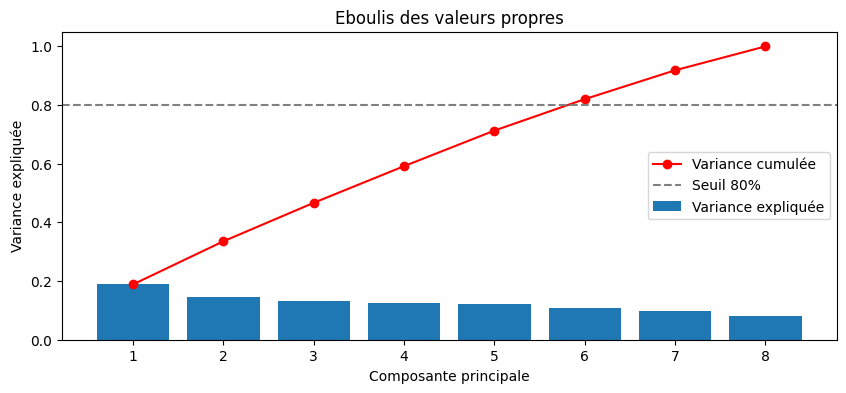

Variance cumulée par composante :
  CP1 : 18.88%
  CP2 : 33.57%
  CP3 : 46.69%
  CP4 : 59.18%
  CP5 : 71.31%
  CP6 : 82.02%
  => 6/8 composantes suffisent pour 80% de variance


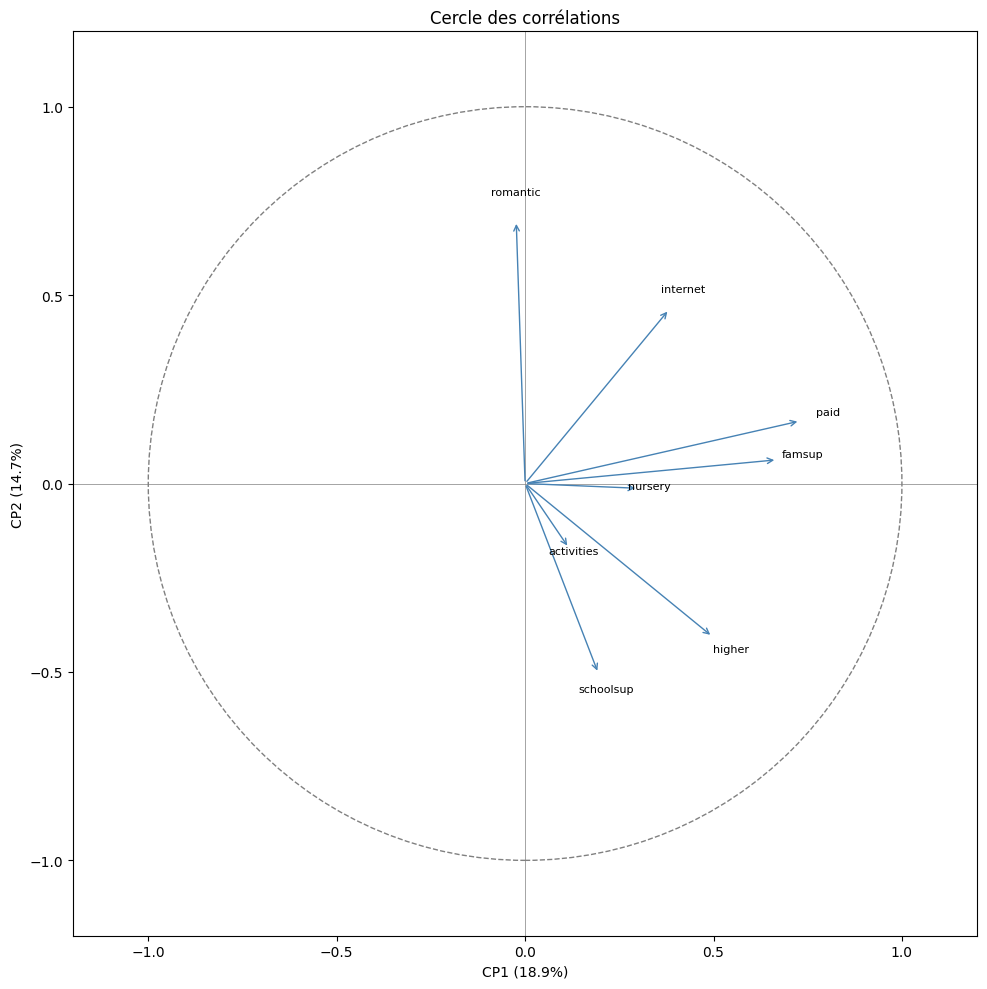

In [48]:
# ---- 1. Séparation numériques / catégorielles ----
num_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
            'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
            'absences', 'G1', 'G2', 'G3']

cat_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus',
            'Mjob', 'Fjob', 'reason', 'guardian']

bool_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'nursery',
             'higher', 'internet', 'romantic']

# ---- 2. Encodage one-hot des catégorielles ----
encoder = OneHotEncoder(sparse_output=False, drop='first')
cat_encoded = encoder.fit_transform(student_mat[cat_cols])
cat_encoded_df = pd.DataFrame(
    cat_encoded,
    columns=encoder.get_feature_names_out(cat_cols)
)

# Booléens en int (True/False -> 1/0)
bool_df = student_mat[bool_cols].astype(int)

# ---- 3. Assemblage du DataFrame final ----
df_acp = pd.concat([
    bool_df.reset_index(drop=True),
], axis=1)

# ---- 4. Centrage-réduction ----
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_acp)

# ---- 5. ACP ----
pca = PCA()
pca.fit(X_scaled)

# ---- 6. Variance expliquée ----
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(10, 4))
plt.bar(range(1, len(explained)+1), explained, label='Variance expliquée')
plt.plot(range(1, len(explained)+1), cumulative, color='red',
         marker='o', label='Variance cumulée')
plt.axhline(y=0.8, color='gray', linestyle='--', label='Seuil 80%')
plt.xlabel('Composante principale')
plt.ylabel('Variance expliquée')
plt.title('Eboulis des valeurs propres')
plt.legend()
plt.show()

print("Variance cumulée par composante :")
for i, v in enumerate(cumulative):
    print(f"  CP{i+1} : {v:.2%}")
    if v >= 0.80:
        print(f"  => {i+1}/{len(bool_cols)} composantes suffisent pour 80% de variance")
        break

# ---- 7. Cercle des corrélations ----
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

# Corrélations variables/composantes
correlations = pca_2.components_.T * np.sqrt(pca_2.explained_variance_)

fig, ax = plt.subplots(figsize=(10, 10))

# Flèches
for i, var in enumerate(df_acp.columns):
    ax.annotate("", xy=(correlations[i, 0], correlations[i, 1]),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="steelblue"))
    ax.text(correlations[i, 0] * 1.1, correlations[i, 1] * 1.1,
            var, fontsize=8, ha='center')

# Cercle
cercle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
ax.add_patch(cercle)

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel(f'CP1 ({pca_2.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'CP2 ({pca_2.explained_variance_ratio_[1]:.1%})')
ax.set_title('Cercle des corrélations')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

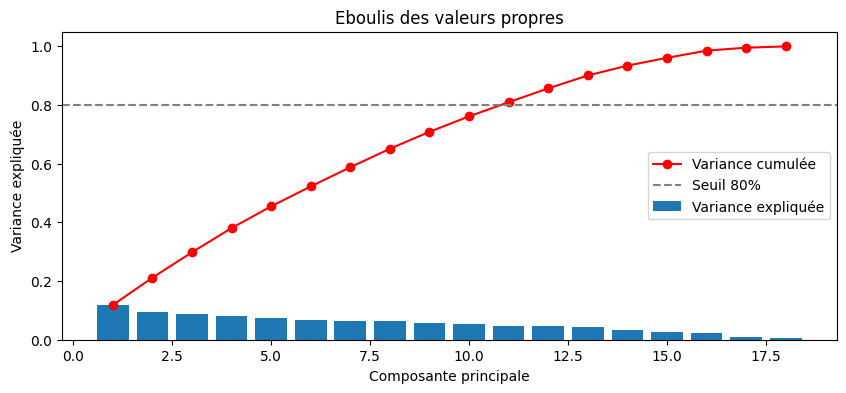

Variance cumulée par composante :
  CP1 : 11.82%
  CP2 : 21.15%
  CP3 : 29.81%
  CP4 : 38.07%
  CP5 : 45.47%
  CP6 : 52.26%
  CP7 : 58.80%
  CP8 : 65.11%
  CP9 : 70.87%
  CP10 : 76.14%
  CP11 : 80.97%
  => 11/9 composantes suffisent pour 80% de variance


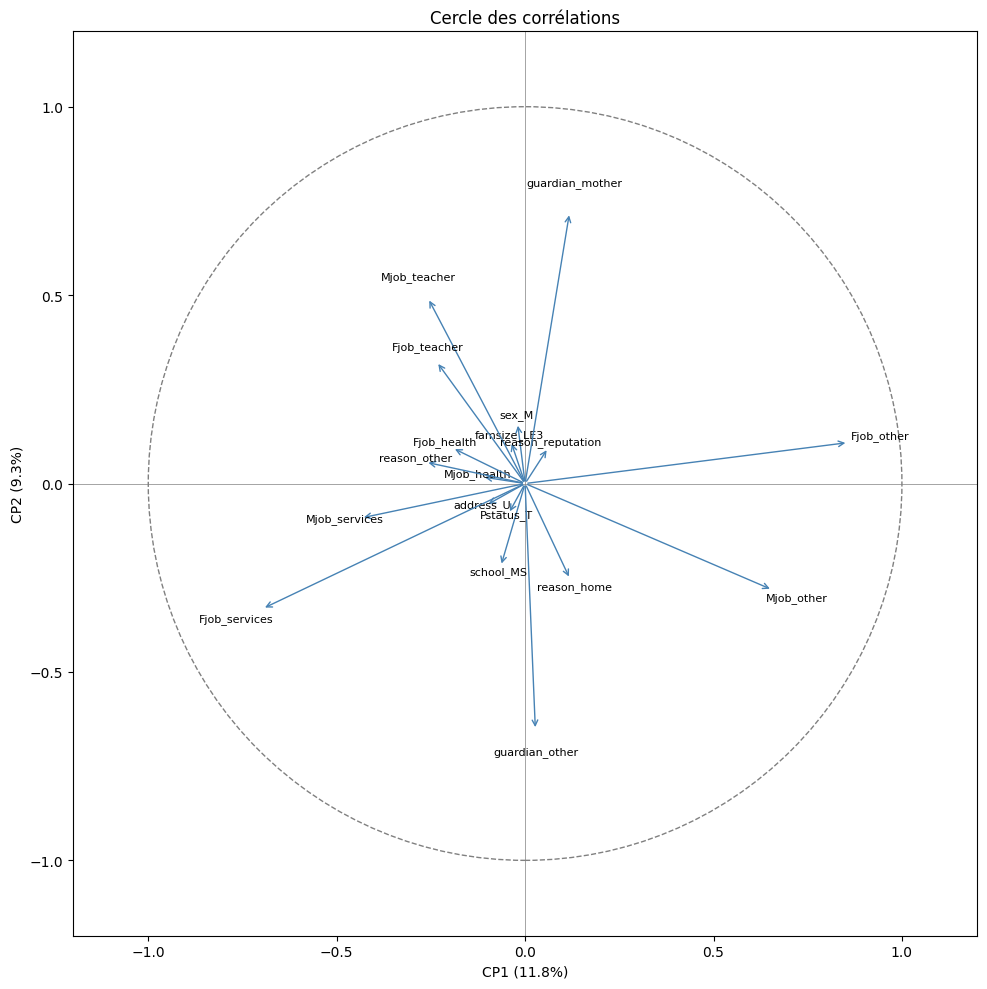

In [51]:
# ---- 1. Séparation numériques / catégorielles ----
num_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
            'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
            'absences', 'G1', 'G2', 'G3']

cat_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus',
            'Mjob', 'Fjob', 'reason', 'guardian']

bool_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'nursery',
             'higher', 'internet', 'romantic']

# ---- 2. Encodage one-hot des catégorielles ----
encoder = OneHotEncoder(sparse_output=False, drop='first')
cat_encoded = encoder.fit_transform(student_mat[cat_cols])
cat_encoded_df = pd.DataFrame(
    cat_encoded,
    columns=encoder.get_feature_names_out(cat_cols)
)

# Booléens en int (True/False -> 1/0)
bool_df = student_mat[bool_cols].astype(int)

# ---- 3. Assemblage du DataFrame final ----
df_acp = pd.concat([
    cat_encoded_df.reset_index(drop=True)
], axis=1)

# ---- 4. Centrage-réduction ----
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_acp)

# ---- 5. ACP ----
pca = PCA()
pca.fit(X_scaled)

# ---- 6. Variance expliquée ----
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(10, 4))
plt.bar(range(1, len(explained)+1), explained, label='Variance expliquée')
plt.plot(range(1, len(explained)+1), cumulative, color='red',
         marker='o', label='Variance cumulée')
plt.axhline(y=0.8, color='gray', linestyle='--', label='Seuil 80%')
plt.xlabel('Composante principale')
plt.ylabel('Variance expliquée')
plt.title('Eboulis des valeurs propres')
plt.legend()
plt.show()

print("Variance cumulée par composante :")
for i, v in enumerate(cumulative):
    print(f"  CP{i+1} : {v:.2%}")
    if v >= 0.80:
        print(f"  => {i+1}/{len(cat_cols)} composantes suffisent pour 80% de variance")
        break

# ---- 7. Cercle des corrélations ----
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

# Corrélations variables/composantes
correlations = pca_2.components_.T * np.sqrt(pca_2.explained_variance_)

fig, ax = plt.subplots(figsize=(10, 10))

# Flèches
for i, var in enumerate(df_acp.columns):
    ax.annotate("", xy=(correlations[i, 0], correlations[i, 1]),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="steelblue"))
    ax.text(correlations[i, 0] * 1.1, correlations[i, 1] * 1.1,
            var, fontsize=8, ha='center')

# Cercle
cercle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
ax.add_patch(cercle)

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel(f'CP1 ({pca_2.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'CP2 ({pca_2.explained_variance_ratio_[1]:.1%})')
ax.set_title('Cercle des corrélations')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## Pairplot

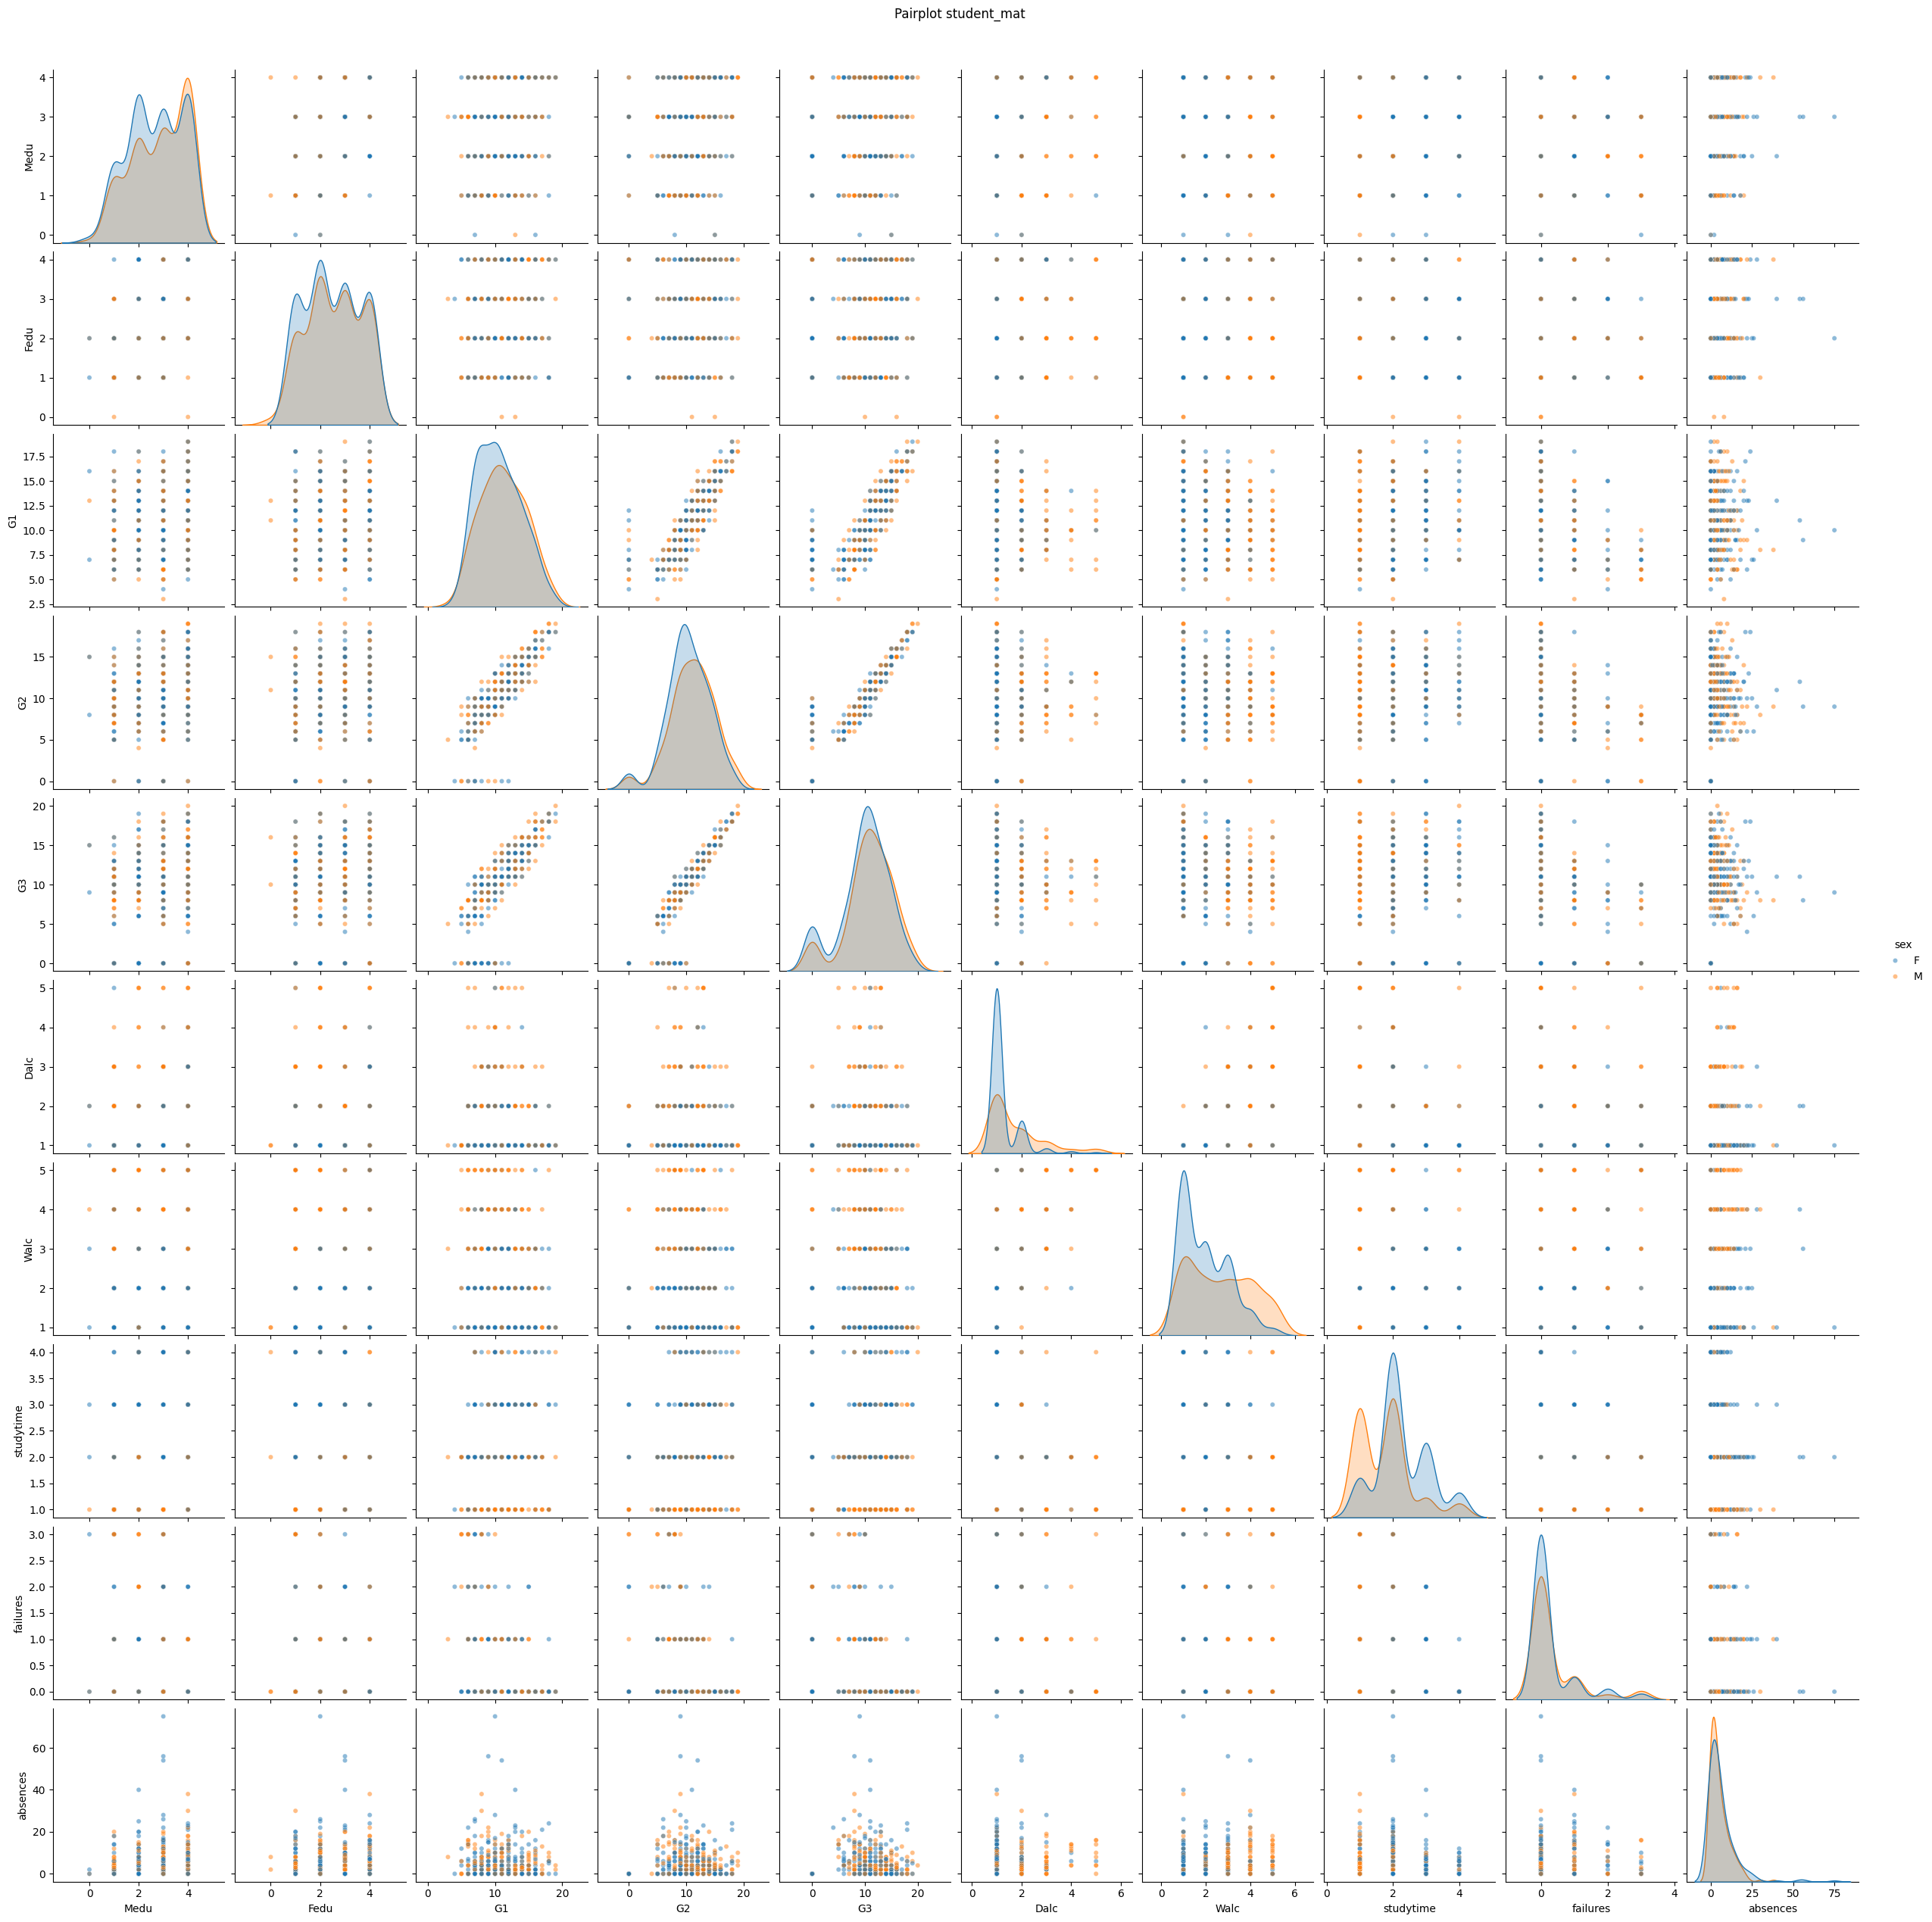

In [55]:
# ---- Pairplot ----
cols_pairplot = ['Medu', 'Fedu', 'G1', 'G2', 'G3', 
                 'Dalc', 'Walc', 'studytime', 'failures', 'absences']

sns.pairplot(
    student_mat[cols_pairplot + ['sex']],
    hue='sex',
    plot_kws={'alpha': 0.5, 's': 20},
    diag_kind='kde'
)
plt.suptitle('Pairplot student_mat', y=1.02)
plt.show()